# <font color="blue">Cuaderno 8 A2.  Red Neuronal Convolucional (CNN) para Reconocimiento de Dígitos Escritos a Mano (MNIST)</h1>
# <font color="red">Alfredo Diaz Claro</h2> </font>

Este cuaderno demuestra la creación, entrenamiento y evaluación de una Red Neuronal Convolucional (CNN) para clasificar dígitos escritos a mano utilizando el conjunto de datos MNIST. El proceso cubre la carga de datos, el preprocesamiento, la definición del modelo, el entrenamiento con parada anticipada, el guardado del modelo y la realización de predicciones en nuevas imágenes.

![imagen](https://images.datacamp.com/image/upload/v1700043905/image10_f8b261ebf1.png)

In [1]:
!python -V

Python 3.13.15


## 1. Configuración e Importaciones

Esta sección importa las librerías necesarias y muestra las versiones de TensorFlow y TensorFlow Datasets, que son cruciales para construir y entrenar la red neuronal.

In [2]:
# Dependencia que falta en este Colab (Python 3.13) para que tensorflow_datasets pueda descargar MNIST
%pip install -q importlib_resources

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.callbacks import EarlyStopping
import math

print(tf.__version__)
print(tfds.__version__)

# --- Guardar los modelos en tu Drive (no se pierden al cerrar Colab) ---
import os
from google.colab import drive
drive.mount('/content/drive')
CARPETA = '/content/drive/MyDrive/modelos_cnn'
os.makedirs(CARPETA, exist_ok=True)
print("Los modelos se guardaran en:", CARPETA)


2.21.0
4.9.10
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Los modelos se guardaran en: /content/drive/MyDrive/modelos_cnn


## 2. Carga y Preprocesamiento de Datos (Conjunto de Datos MNIST)

Aquí se carga el conjunto de datos MNIST, que consta de 60,000 imágenes de entrenamiento y 10,000 imágenes de prueba de dígitos escritos a mano (0-9). Se define una función `normalizar` para escalar los valores de los píxeles de [0, 255] a [0, 1] y para añadir una dimensión de canal, lo cual es necesario para las capas convolucionales. Los datos preprocesados se almacenan en caché para un entrenamiento más rápido.

In [3]:
# Descargar set de datos de MNIST (números escritos a mano, etiquetados)
datos, metadatos = tfds.load('mnist', as_supervised=True, with_info=True)

# Obtener en variables separadas los datos de entrenamiento (60k) y pruebas (10k)
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

# Función de normalización para los datos (pasar valores de los píxeles de 0-255 a 0-1)
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32) / 255.0  # Normalizar a [0, 1]
    imagenes = tf.expand_dims(imagenes, axis=-1)  # Añadir el canal de profundidad
    return imagenes, etiquetas

# Normalizar los datos de entrenamiento y prueba
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)


# Agregar a cache (usar memoria en lugar de disco, entrenamiento más rápido)
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()
clases = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.CJ5D09_3.0.1/mnist-train.tfrecord-[0-9][0-9][0-9][0-9][0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.CJ5D09_3.0.1/mnist-test.tfrecord-[0-9][0-9][0-9][0-9][0-9…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


## 3. Visualización de Datos

Este bloque de código utiliza `matplotlib` para mostrar las primeras 25 imágenes del conjunto de datos de entrenamiento, junto con sus etiquetas correspondientes. Esto ayuda a inspeccionar visualmente los datos con los que se entrenará el modelo.

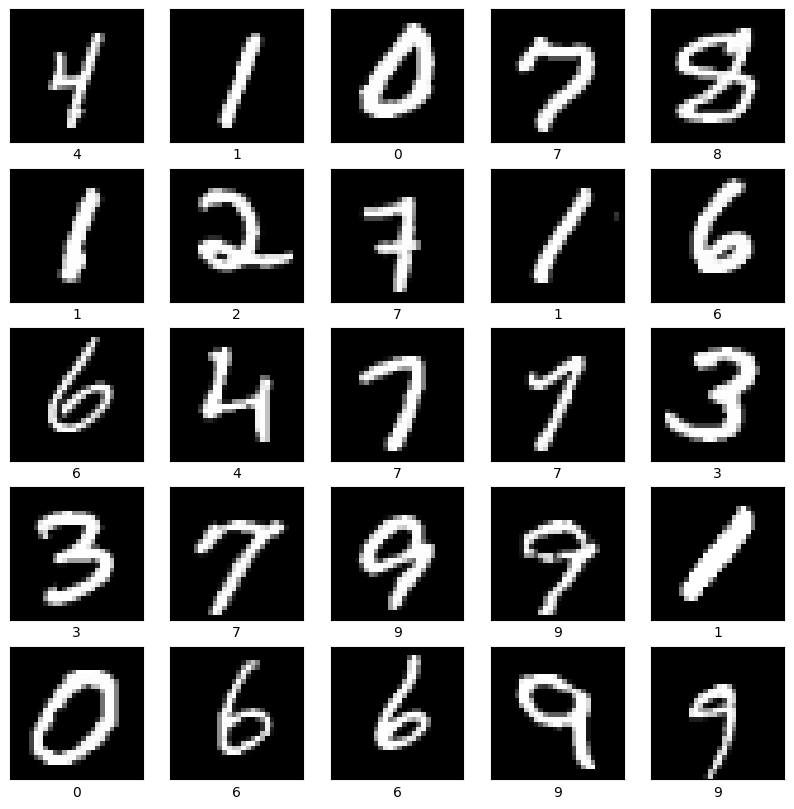

In [4]:
#Codigo para mostrar imagenes del set, no es necesario ejecutarlo, solo imprime unos numeros :)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
  imagen = imagen.numpy().reshape((28,28))
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(imagen, cmap=plt.cm.binary_r)
  plt.xlabel(clases[etiqueta])

plt.show()

## 4. Arquitectura del Modelo: Red Neuronal Convolucional (CNN)

Esta sección define el modelo CNN utilizando `tf.keras.Sequential`. La arquitectura del modelo incluye:

-   **Capa de Entrada**: Especifica la forma de entrada esperada para las imágenes (28x28 píxeles, 1 canal para escala de grises).
-   **Capas Convolucionales (Conv2D)**: Dos capas convolucionales con activación ReLU, diseñadas para extraer características de las imágenes.
    -   La primera capa `Conv2D` tiene 32 filtros de tamaño (3,3).
    -   La segunda capa `Conv2D` tiene 64 filtros de tamaño (3,3).
-   **Capas de Agrupamiento Máximo (MaxPooling2D)**: Dos capas de agrupamiento máximo reducen las dimensiones espaciales de los mapas de características, ayudando a reducir el costo computacional y a controlar el sobreajuste.
-   **Capa de Aplanamiento (Flatten)**: Convierte los mapas de características 2D en un vector 1D para que pueda ser introducido en las capas densas.
-   **Capas Densas**: Dos capas densas ocultas con activación ReLU y una capa densa de salida final con 10 unidades (para 10 clases) y activación `softmax` para generar distribuciones de probabilidad.

Este es un modelo de red neuronal convolucional (CNN) diseñado para trabajar con imágenes de 28x28 píxeles, como las del conjunto de datos MNIST. El modelo consta de varias capas, que son:

**Capa de entrada (Input):** Define la forma de entrada de las imágenes. En este caso, las imágenes son en escala de grises con una dimensión de (28, 28, 1).


**Capas de convolución (Conv2D):**


**Conv2D(32, (3, 3), activation='relu'):**

32: Número de filtros (kernels). Cada filtro aprenderá a detectar características diferentes en las imágenes.
(3, 3): Tamaño del kernel. Es un filtro de 3x3 píxeles.
activation='relu': Función de activación que introduce no linealidad.

**Capas de agrupamiento (MaxPooling2D):**

MaxPooling2D((2, 2)): Esta capa reduce las dimensiones espaciales de la salida de la capa anterior. En este caso, se aplica un agrupamiento de 2x2, que toma el valor máximo en cada ventana de 2x2, reduciendo así la resolución.
Capa de aplanamiento (Flatten): Convierte la salida de las capas anteriores en un vector unidimensional para que pueda ser procesado por las capas densas.

![image](https://miro.medium.com/v2/resize:fit:1400/0*QIvqCOigRiq1Gmnc.png)

**Capas densas (Dense):**

La primera capa densa tiene 100 unidades y usa la activación ReLU.
La última capa densa tiene 10 unidades (una por cada clase en el conjunto de datos MNIST) y usa la activación softmax para obtener probabilidades.
Determinación de los Kernels

Los kernels (o filtros) en las capas de convolución son matrices pequeñas que se deslizan (convolucionan) sobre la imagen de entrada para extraer características. Aquí hay algunos puntos clave sobre su determinación y uso:

**Tamaño del Kernel:**

En este caso, el kernel tiene un tamaño de (3, 3). Este tamaño se elige a menudo en función de las características que se desean detectar. Kernels más pequeños (como 3x3 o 5x5) son comunes porque pueden capturar patrones locales de manera efectiva.
Número de Filtros:

En Conv2D(32, ...), el número 32 indica que se están utilizando 32 filtros diferentes. Cada filtro se entrena para aprender diferentes características de la imagen (bordes, texturas, etc.).
Entrenamiento:


Los valores de los kernels son parámetros que se ajustan durante el entrenamiento del modelo. Al inicio, los valores se inicializan aleatoriamente, y durante el entrenamiento, a través del proceso de retropropagación, se ajustan en función del error del modelo.




In [5]:
#Crear el modelo (Ya utiliza capas de convolución y agrupación)
#Cuenta con 1 capa de convolución con 32 núcleos y otra con 64. 2 capas de agrupación.
#Finalmente una capa densa con 100 neuronas
# Crear el modelo
modelo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),  # Usar Input para definir la forma de entrada
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2), padding="same"),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=10, activation='softmax')
])


# Compilar el modelo
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

## 5. Compilación del Modelo

El modelo se compila con las siguientes configuraciones:

-   **Optimizador**: `adam`, un popular algoritmo de optimización.
-   **Función de Pérdida**: `SparseCategoricalCrossentropy`, adecuada para clasificación multiclase cuando las etiquetas son números enteros.
-   **Métricas**: `accuracy` para monitorear el rendimiento del modelo durante el entrenamiento.

In [6]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,746 (659.16 KB)

 Trainable params: 168,746 (659.16 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Resumen del Modelo

`modelo.summary()` muestra un resumen detallado de la arquitectura del modelo, incluyendo la forma de salida de cada capa y el número de parámetros entrenables. Esto es útil para comprender la complejidad del modelo y el consumo de memoria.

In [7]:
# Trabajar por lotes
TAMANO_LOTE = 32

# Shuffle y repeat hacen que los datos estén mezclados de manera aleatoria
# para que el entrenamiento no se aprenda en orden
datos_entrenamiento = datos_entrenamiento.shuffle(10000).batch(TAMANO_LOTE).repeat()
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

## 7. Agrupación y Mezclado de Datos

Antes del entrenamiento, los conjuntos de datos se agrupan en lotes de `TAMANO_LOTE` (32 imágenes). Los datos de entrenamiento se mezclan y se repiten para asegurar que el modelo vea diferentes permutaciones de los datos en cada época, lo que ayuda a una mejor generalización y previene el sobreajuste.

In [8]:
# Configurar EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Realizar el entrenamiento
num_datos_entrenamiento = metadatos.splits['train'].num_examples
num_datos_entrenamiento

60000

## 8. Entrenamiento del Modelo

Esta sección entrena el modelo CNN utilizando los conjuntos de datos de entrenamiento y validación preparados. La parada anticipada (early stopping) se configura para monitorear la pérdida de validación (`val_loss`) y detener el entrenamiento si no mejora durante 5 épocas consecutivas, restaurando los mejores pesos encontrados durante el entrenamiento. El objeto `historial` almacena el progreso del entrenamiento.

In [9]:
# Realizar el entrenamiento
historial = modelo.fit(
    datos_entrenamiento,
    epochs=50,
    steps_per_epoch=math.ceil(num_datos_entrenamiento / TAMANO_LOTE),
    validation_data=datos_pruebas,
    validation_steps=math.ceil(len(list(datos_pruebas)) / TAMANO_LOTE),
    callbacks=[early_stopping]
)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.9511 - loss: 0.1557 - val_accuracy: 0.9906 - val_loss: 0.0374
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9843 - loss: 0.0498 - val_accuracy: 0.9844 - val_loss: 0.0316
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9893 - loss: 0.0345 - val_accuracy: 0.9937 - val_loss: 0.0212
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9915 - loss: 0.0263 - val_accuracy: 0.9906 - val_loss: 0.0204
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9938 - loss: 0.0189 - val_accuracy: 0.9969 - val_loss: 0.0096
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9948 - loss: 0.0155 - val_accuracy: 0.9906 - val_loss: 0.0444
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9960 - loss: 0.0127 - val_accuracy: 0.9906 - val_loss: 0.0405
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9963 - loss: 0.0109

## 9. Guardar el Modelo

Después del entrenamiento, el modelo se guarda en el formato nativo de Keras (`.keras`). Esto permite cargar y reutilizar fácilmente el modelo entrenado sin necesidad de volver a entrenarlo.

In [10]:
# Guardar el modelo en el formato nativo de Keras (directo en tu Drive)
modelo.save(f'{CARPETA}/mnist_conv2d.keras')
#modelo.save(f'{CARPETA}/mnist_conv2d.h5')

## 10. Guardar Arquitectura y Pesos del Modelo

Esta celda guarda la arquitectura del modelo como un archivo JSON y sus pesos por separado como un archivo H5. Esto puede ser útil para escenarios donde se necesita cargar la arquitectura y los pesos de forma independiente, o cuando se trabaja con versiones anteriores de TensorFlow que podrían preferir estos formatos para portabilidad o escenarios de despliegue específicos.

In [11]:
model_json = modelo.to_json()
with open(f'{CARPETA}/mnist_conv2d.json', 'w') as json_file:
    json_file.write(model_json)
modelo.save_weights(f'{CARPETA}/mnist_conv2d.weights.h5') # Change the file name to end with .weights.h5

## 11. Conversión a TensorFlow.js (Comentado)

Esta sección proporciona código comentado para convertir el modelo de Keras al formato TensorFlow.js. Esto es útil para desplegar modelos de aprendizaje automático directamente en navegadores web o entornos Node.js.

In [12]:
#Exportar el modelo al explorador! (Mas detalle de esto en en mi video de exportacion: https://youtu.be/JpE4bYyRADI )
#modelo.save('numeros_conv.h5')

#Convertirlo a tensorflow.js
#!pip install tensorflowjs

#!mkdir carpeta_salida

#!tensorflowjs_converter --input_format keras numeros_conv.h5 carpeta_salida

## 12. Mostrar Precisión Final

Esta celda imprime la precisión final de entrenamiento y validación alcanzada por el modelo después del entrenamiento, que son métricas importantes para evaluar el rendimiento del modelo.

In [13]:
# Print the final training and validation accuracy
print("Final Training Accuracy: {:.4f}".format(historial.history['accuracy'][-1]))
print("Final Validation Accuracy: {:.4f}".format(historial.history['val_accuracy'][-1]))

Final Training Accuracy: 0.9973
Final Validation Accuracy: 0.9937


## 13. Descargar Imagen para Predicción

Este bloque de código descarga una imagen de un dígito escrito a mano desde una URL especificada y la guarda como `numero2.jpg`. Esta imagen se utilizará para probar el modelo entrenado.

## Descargar Imagen


In [14]:
import requests

url = "https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/numero9.jpg"
response = requests.get(url)

if response.status_code == 200:
    with open("numero2.jpg", "wb") as f:
        f.write(response.content)
    print("Image downloaded successfully as numero2.jpg")
else:
    print(f"Failed to download image. Status code: {response.status_code}")

Image downloaded successfully as numero2.jpg


## 14. Mostrar Imagen Descargada

Esta celda utiliza `IPython.display.Image` para mostrar la imagen descargada dentro del cuaderno, lo que permite verificar que se obtuvo la imagen correcta.

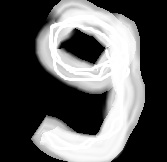

In [15]:
#mostrar imagen en colab
from IPython.display import Image
Image(filename='numero2.jpg')

## 15. Preprocesamiento de Imagen para Predicción

Antes de introducir la imagen descargada al modelo CNN entrenado, debe preprocesarse de la misma manera que se hizo con los datos de entrenamiento. Esto implica:

1.  **Cargar en escala de grises**: Leer la imagen como un solo canal.
2.  **Redimensionar**: Cambiar las dimensiones de la imagen a 28x28 píxeles.
3.  **Normalizar**: Escalar los valores de los píxeles de [0, 255] a [0, 1].
4.  **Añadir Dimensión de Canal**: Expandir las dimensiones a (28, 28, 1).
5.  **Añadir Dimensión de Lote**: Expandir las dimensiones a (1, 28, 28, 1) ya que el modelo espera un lote de imágenes.

## Preprocesamiento de la imagen


In [16]:
import cv2
import numpy as np

# Load the image in grayscale
image_path = 'numero2.jpg'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Resize the image to 28x28
image_resized = cv2.resize(image, (28, 28))

# Normalize the pixel values to [0, 1]
image_normalized = image_resized.astype(np.float32) / 255.0

# Add a channel dimension
image_preprocessed = np.expand_dims(image_normalized, axis=-1)

# Add a batch dimension (the model expects a batch of images)
image_preprocessed = np.expand_dims(image_preprocessed, axis=0)

print("Image preprocessed successfully. Shape:", image_preprocessed.shape)

Image preprocessed successfully. Shape: (1, 28, 28, 1)


## 16. Predecir el Dígito

Esta sección utiliza el `modelo` entrenado para hacer una predicción sobre la imagen preprocesada. La función `modelo.predict()` devuelve probabilidades para cada clase de dígito. Luego se utiliza `np.argmax()` para encontrar el dígito con la probabilidad predicha más alta.

## Predecir el digito




In [17]:
# Use the trained model to predict the digit
predictions = modelo.predict(image_preprocessed)

# Get the predicted digit (index with the highest probability)
predicted_digit = np.argmax(predictions)

print(f"The predicted digit is: {predicted_digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 878ms/step
The predicted digit is: 3


## 17. Mostrar la Predicción

Finalmente, el dígito predicho obtenido del modelo se imprime en la consola.

## Desplegamos la predicción



In [18]:
print(f"The predicted digit is: {predicted_digit}")

The predicted digit is: 3


## 18. Gráfico del Historial de Entrenamiento (Precisión y Pérdida)

Este bloque de código visualiza la precisión y la pérdida de entrenamiento y validación a lo largo de las épocas. Se generan dos subgráficos:

-   **Gráfico de Precisión**: Muestra cómo evolucionaron tanto la precisión de entrenamiento como la de validación durante el proceso de entrenamiento.
-   **Gráfico de Pérdida**: Muestra la pérdida de entrenamiento y validación a lo largo de las épocas. Estos gráficos son cruciales para entender si el modelo está sobreajustándose, subajustándose o entrenándose de manera efectiva.

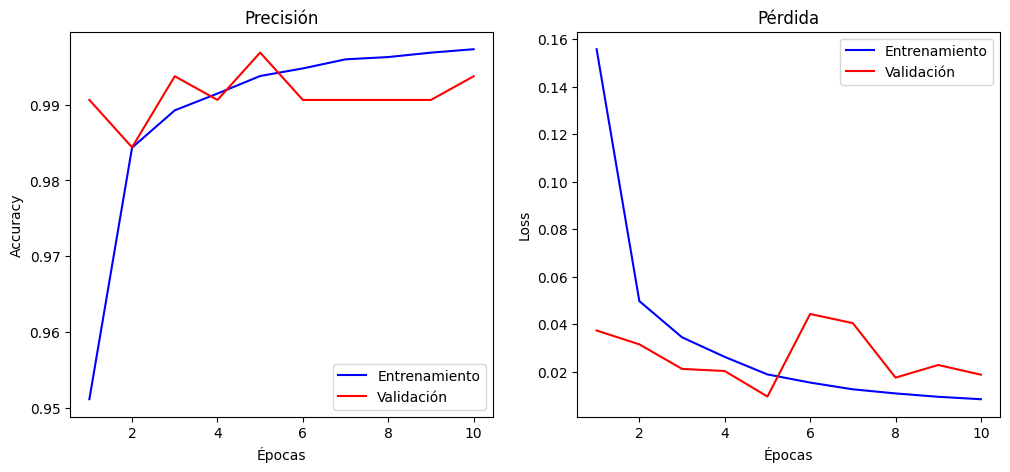

In [19]:
# Extraer métricas del historial
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']

epocas = range(1, len(acc) + 1)

# Gráfica de precisión
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epocas, acc, 'b-', label='Entrenamiento')
plt.plot(epocas, val_acc, 'r-', label='Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Gráfica de pérdida
plt.subplot(1, 2, 2)
plt.plot(epocas, loss, 'b-', label='Entrenamiento')
plt.plot(epocas, val_loss, 'r-', label='Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.show()